# 1. EDA dữ liệu ViSignLanguage-Video

## Import thư viện

In [1]:
import os
from pathlib import Path
from collections import defaultdict

import cv2
import pandas as pd
import matplotlib.pyplot as plt

## Cấu hình đường dẫn

In [ ]:
ROOT_DIR = "../data/train"
OUTPUT_DIR = "../results/eda_output"
VIDEO_EXT = (".mp4",)

## Hàm đọc metadata của 1 video

In [3]:
def get_video_info(video_path: str):
    """Trả về (num_frames, fps, duration_sec, width, height) của 1 video.
    Trả về None nếu video lỗi không đọc được."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    if fps <= 0 or num_frames <= 0:
        return None

    duration_sec = num_frames / fps
    return num_frames, fps, duration_sec, width, height

## Hàm quét toàn bộ dataset

In [4]:
def audit_dataset(root_dir: str, video_ext=(".mp4",)):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Không tìm thấy thư mục: {root_dir}")

    class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    if not class_dirs:
        raise ValueError(
            "Không tìm thấy thư mục con nào trong ROOT_DIR. Kiểm tra lại cấu trúc dataset."
        )

    records = []
    broken_videos = []

    print(f"Tìm thấy {len(class_dirs)} class. Đang quét video...\n")

    for class_dir in class_dirs:
        class_name = class_dir.name
        videos = [f for f in class_dir.iterdir() if f.suffix.lower() in video_ext]

        for video_path in videos:
            info = get_video_info(str(video_path))
            if info is None:
                broken_videos.append(str(video_path))
                continue
            num_frames, fps, duration_sec, width, height = info
            records.append({
                "class": class_name,
                "filename": video_path.name,
                "num_frames": num_frames,
                "fps": round(fps, 2),
                "duration_sec": round(duration_sec, 3),
                "width": width,
                "height": height,
            })

    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError("Không đọc được video nào. Kiểm tra lại đường dẫn / định dạng file.")

    return df, broken_videos, class_dirs

## Hàm in báo cáo tổng quan

In [5]:
def print_summary(df: pd.DataFrame, broken_videos: list, num_classes: int):
    print("=" * 60)
    print("TỔNG QUAN DATASET")
    print("=" * 60)
    print(f"Tổng số video đọc được : {len(df)}")
    print(f"Số class               : {num_classes}")
    print(f"Video lỗi/không đọc được: {len(broken_videos)}")
    if broken_videos:
        print("  -> Danh sách lưu trong broken_videos.txt")

    print("\n--- PHÂN BỐ SỐ VIDEO / CLASS ---")
    class_counts = df["class"].value_counts()
    print(f"Min  : {class_counts.min()}  (class: {class_counts.idxmin()})")
    print(f"Max  : {class_counts.max()}  (class: {class_counts.idxmax()})")
    print(f"Mean : {class_counts.mean():.1f}")
    print(f"Median: {class_counts.median():.1f}")
    imbalance_ratio = class_counts.max() / max(class_counts.min(), 1)
    print(f"Tỷ lệ mất cân bằng (max/min): {imbalance_ratio:.1f}x")

    print("\n--- PHÂN BỐ SỐ FRAME / VIDEO ---")
    print(df["num_frames"].describe(percentiles=[.1, .25, .5, .75, .9, .95]))

    print("\n--- PHÂN BỐ FPS ---")
    print(df["fps"].value_counts().head(10))

    print("\n--- PHÂN BỐ RESOLUTION ---")
    res_counts = df.groupby(["width", "height"]).size().sort_values(ascending=False)
    print(res_counts.head(10))

## Hàm vẽ biểu đồ phân bố

In [6]:
def plot_distributions(df: pd.DataFrame, output_dir: str):
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Phân bố số video/class
    fig, ax = plt.subplots(figsize=(12, 5))
    df["class"].value_counts().plot(kind="bar", ax=ax)
    ax.set_title("Số lượng video theo class")
    ax.set_xlabel("Class")
    ax.set_ylabel("Số video")
    plt.xticks(rotation=90, fontsize=6)
    plt.tight_layout()
    fig.savefig(f"{output_dir}/videos_per_class.png", dpi=120)
    plt.show()

    # Phân bố độ dài (số frame)
    fig, ax = plt.subplots(figsize=(8, 5))
    df["num_frames"].hist(bins=40, ax=ax)
    ax.set_title("Phân bố số frame / video")
    ax.set_xlabel("Số frame")
    ax.set_ylabel("Số video")
    plt.tight_layout()
    fig.savefig(f"{output_dir}/frame_distribution.png", dpi=120)
    plt.show()

    # Phân bố duration (giây)
    fig, ax = plt.subplots(figsize=(8, 5))
    df["duration_sec"].hist(bins=40, ax=ax)
    ax.set_title("Phân bố thời lượng video (giây)")
    ax.set_xlabel("Giây")
    ax.set_ylabel("Số video")
    plt.tight_layout()
    fig.savefig(f"{output_dir}/duration_distribution.png", dpi=120)
    plt.show()

    print(f"\nĐã lưu 3 biểu đồ vào: {output_dir}/")

## Chạy phân tích toàn bộ dataset

In [8]:
df, broken_videos, class_dirs = audit_dataset(ROOT_DIR, video_ext=VIDEO_EXT)
df.head()

Tìm thấy 100 class. Đang quét video...



,class,filename,num_frames,fps,duration_sec,width,height
0,An ủi,126225.mp4,30,9.34,3.212,224,224
1,An ủi,127824.mp4,30,12.50,2.400,224,224
2,An ủi,127824_1.mp4,30,12.50,2.400,224,224
3,An ủi,127824_2.mp4,30,12.50,2.400,224,224
4,An ủi,127824_3.mp4,30,12.50,2.400,224,224


## In báo cáo tổng quan

In [9]:
print_summary(df, broken_videos, len(class_dirs))

TỔNG QUAN DATASET
Tổng số video đọc được : 3049
Số class               : 100
Video lỗi/không đọc được: 0

--- PHÂN BỐ SỐ VIDEO / CLASS ---
Min  : 6  (class: Xe máy)
Max  : 52  (class: Trường học)
Mean : 30.5
Median: 35.0
Tỷ lệ mất cân bằng (max/min): 8.7x

--- PHÂN BỐ SỐ FRAME / VIDEO ---
count    3049.000000
mean       27.443752
std         5.517171
min         9.000000
10%        17.000000
25%        30.000000
50%        30.000000
75%        30.000000
90%        30.000000
95%        30.000000
max        30.000000
Name: num_frames, dtype: float64

--- PHÂN BỐ FPS ---
fps
14.06    219
12.17     88
12.50     70
11.11     63
11.25     59
13.64     56
11.84     55
10.71     50
12.68     50
13.44     43
Name: count, dtype: int64

--- PHÂN BỐ RESOLUTION ---
width  height
224    224       3049
dtype: int64


**Nhận xét**:
- Tỉ lệ video trong mỗi class bị mất cân bằng (class có nhiều video nhất gấp 8.7 lần class ít nhất) --> Cần data augmentation và thêm `class_weight` khi train model để tránh việc model thiên vị class nhiều mẫu.
- Phân bố số frame mỗi video chủ yếu là 30 frame --> Chọn số frame cố định cho tất cả video để resample là 30 frame.

## Vẽ biểu đồ phân bố

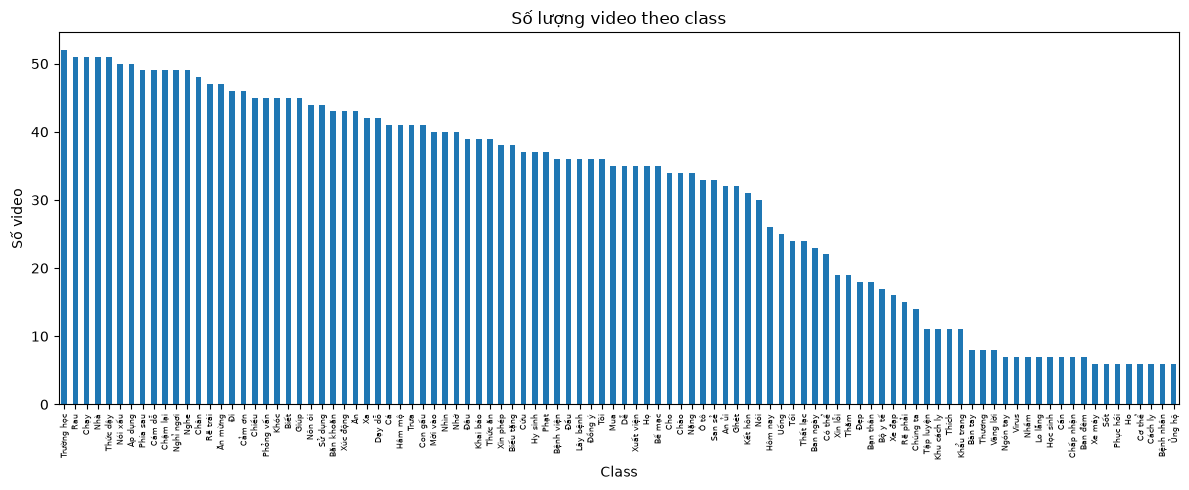

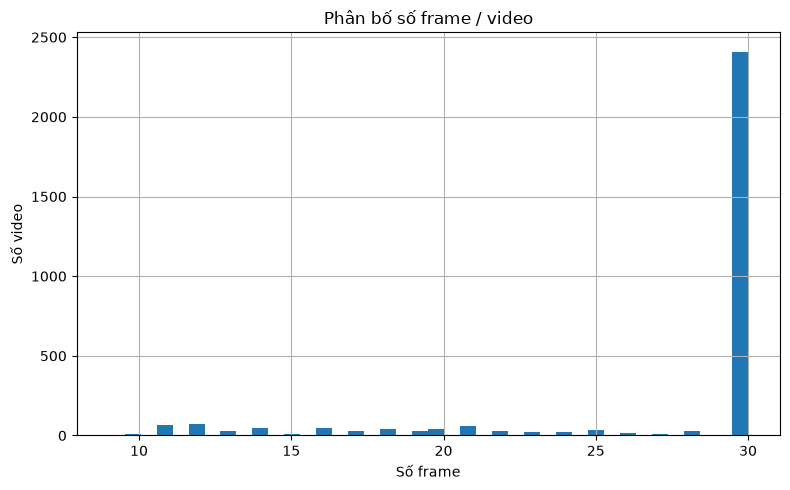

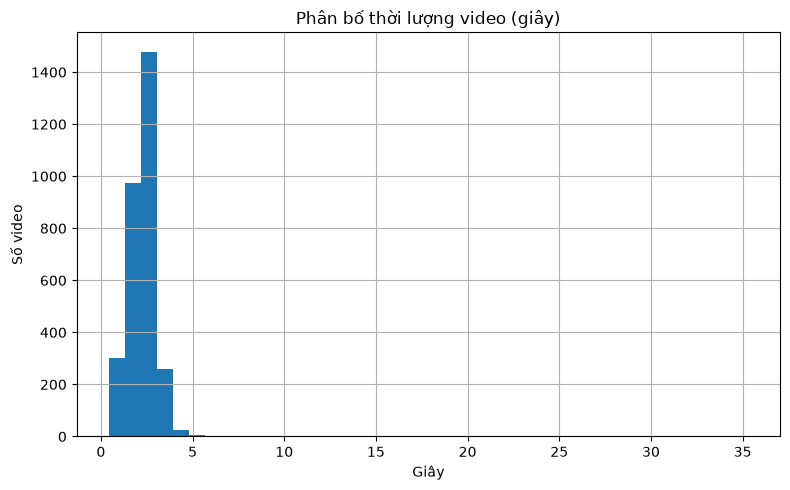


Đã lưu 3 biểu đồ vào: ../results/eda_output/


In [10]:
plot_distributions(df, OUTPUT_DIR)

## Lưu kết quả chi tiết ra file

In [11]:
df.to_csv(f"{OUTPUT_DIR}/video_metadata.csv", index=False, encoding="utf-8-sig")
if broken_videos:
    with open(f"{OUTPUT_DIR}/broken_videos.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(broken_videos))

print(f"Đã lưu bảng chi tiết vào: {OUTPUT_DIR}/video_metadata.csv")

Đã lưu bảng chi tiết vào: ../results/eda_output/video_metadata.csv


# 2. Chọn lọc 30 class nhiều video nhất


In [ ]:
def select_top_n_classes(df: pd.DataFrame, n_classes: int = 30):
    """
    Chọn n_classes có nhiều video nhất, dựa trên df đã có từ bước EDA.
    Trả về pandas Series: index = tên class, value = số video.
    """
    class_counts = df["class"].value_counts()
    top_classes = class_counts.head(n_classes)

    print(f"Tổng số class ban đầu: {len(class_counts)}")
    print(f"Chọn {len(top_classes)} class nhiều video nhất\n")
    print(f"{'Class':<25} {'Số video':>10}")
    print("-" * 36)
    for cls, cnt in top_classes.items():
        print(f"{cls:<25} {cnt:>10}")

    print(f"\nTổng video trong {n_classes} class đã chọn: {top_classes.sum()}")
    print(f"Min: {top_classes.min()}  Max: {top_classes.max()}  "
          f"Ratio mất cân bằng: {top_classes.max() / top_classes.min():.2f}x")

    dropped = class_counts.index.difference(top_classes.index)
    print(f"Số class bị loại: {len(dropped)}")

    return top_classes

In [11]:
import shutil

def create_filtered_dataset(class_dirs, output_root_dir: str, selected_class_names):
    output_root = Path(output_root_dir)
    output_root.mkdir(parents=True, exist_ok=True)

    class_dir_map = {d.name: d for d in class_dirs}
    n_copied = 0

    for class_name in selected_class_names:
        src_dir = class_dir_map.get(class_name)
        dst_dir = output_root / class_name

        if src_dir is None:
            print(f"CẢNH BÁO: không tìm thấy thư mục gốc cho class '{class_name}', bỏ qua.")
            continue
        if dst_dir.exists():
            continue

        shutil.copytree(src_dir, dst_dir)
        n_copied += 1

    print(f"\nĐã copy {n_copied} class vào: {output_root_dir}")

In [ ]:
df = pd.read_csv(f"{OUTPUT_DIR}/video_metadata.csv", encoding="utf-8-sig")

top_classes = select_top_n_classes(df, n_classes=30)

root = Path("../data/train")
class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
create_filtered_dataset(
    class_dirs=class_dirs,
    output_root_dir="../data/ViSignLanguage-Video-Top30",
    selected_class_names=top_classes.index,
)

Tổng số class ban đầu: 100
Chọn 30 class nhiều video nhất

Class                       Số video
------------------------------------
Trường học                        52
Rau                               51
Chạy                              51
Nhà                               51
Thức dậy                          51
Nói xấu                           50
Áp dụng                           50
Phía sau                          49
Cám dỗ                            49
Chậm lại                          49
Nghỉ ngơi                         49
Nghe                              49
Chân                              48
Rẽ trái                           47
Ăn mừng                           47
Đi                                46
Cảm ơn                            46
Chiều                             45
Phỏng vấn                         45
Khóc                              45
Biết                              45
Giúp                              45
Nôn ói                            44
Sử dụng         

# 3. Trích xuất keypoints và tiền xử lí dữ liệu

Các quyết định đã chốt từ bước EDA dữ liệu:
- T = 30 (fixed-length), vì percentile 75-95 số frame đều = 30.
- Resample theo frame index chứ không theo giây, vì FPS của bộ dữ liệu không đồng nhất.

Feature vector: 534 chiều/frame, bao gồm:
- **Pose**: 33 điểm × (x,y,z,visibility) = 132
- **Face subset**: 92 điểm × (x,y,z) = 276 (chỉ lấy vùng mắt/mày/miệng, lấy trực tiếp từ `FACEMESH_LIPS`, `FACEMESH_LEFT_EYE`, `FACEMESH_LEFT_EYEBROW`, `FACEMESH_RIGHT_EYE`, `FACEMESH_RIGHT_EYEBROW` của `mp.solutions.face_mesh`)
- **Left hand**: 21 × 3 = 63
- **Right hand**: 21 × 3 = 63
- **Tổng: 132 + 276 + 63 + 63 = 534**

In [ ]:
import os
import cv2
import numpy as np
import json
from pathlib import Path
from tqdm import tqdm

import mediapipe as mp
mp_holistic = mp.solutions.holistic
mp_face_mesh = mp.solutions.face_mesh

## Cấu hình

In [18]:
ROOT_DIR = "../data/ViSignLanguage-Video-Top30"
OUTPUT_DIR = "../results/keypoints_output_holistic"
T = 30  # fixed-length num_frames

Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

## Xác định subset landmark khuôn mặt (mắt/mày/miệng)

In [3]:
def _unique_indices(connections):
    idx = set()
    for a, b in connections:
        idx.add(a); idx.add(b)
    return idx

_lips = _unique_indices(mp_face_mesh.FACEMESH_LIPS)
_left_eye = _unique_indices(mp_face_mesh.FACEMESH_LEFT_EYE)
_left_eyebrow = _unique_indices(mp_face_mesh.FACEMESH_LEFT_EYEBROW)
_right_eye = _unique_indices(mp_face_mesh.FACEMESH_RIGHT_EYE)
_right_eyebrow = _unique_indices(mp_face_mesh.FACEMESH_RIGHT_EYEBROW)

FACE_SUBSET_IDX = sorted(_lips | _left_eye | _left_eyebrow | _right_eye | _right_eyebrow)
N_FACE = len(FACE_SUBSET_IDX)

# Vị trí (trong FACE_SUBSET_IDX) của 2 điểm khoé mắt ngoài, dùng để scale
FACE_SCALE_I = FACE_SUBSET_IDX.index(33)   # khoé mắt phải (ngoài)
FACE_SCALE_J = FACE_SUBSET_IDX.index(263)  # khoé mắt trái (ngoài)

print(f"Số điểm face subset: {N_FACE}")
print(f"Feature vector/frame: pose(132) + face({N_FACE*3}) + left_hand(63) + right_hand(63) "
      f"= {132 + N_FACE*3 + 63 + 63}")

Số điểm face subset: 92
Feature vector/frame: pose(132) + face(276) + left_hand(63) + right_hand(63) = 534


## Hàm detect + trích xuất landmark 1 frame

Trả về 4 array chứa landmarks (pose, face, left_hand, right_hand) của 1 frame:

In [4]:
def extract_frame_landmarks(image_rgb, holistic_model):
    results = holistic_model.process(image_rgb)

    if results.pose_landmarks:
        pose = np.array(
            [[lm.x, lm.y, lm.z, lm.visibility] for lm in results.pose_landmarks.landmark],
            dtype=np.float32,
        )
    else:
        pose = np.full((33, 4), np.nan, dtype=np.float32)

    if results.face_landmarks:
        all_face = results.face_landmarks.landmark
        face = np.array(
            [[all_face[i].x, all_face[i].y, all_face[i].z] for i in FACE_SUBSET_IDX],
            dtype=np.float32,
        )
    else:
        face = np.full((N_FACE, 3), np.nan, dtype=np.float32)

    if results.left_hand_landmarks:
        lh = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark],
            dtype=np.float32,
        )
    else:
        lh = np.full((21, 3), np.nan, dtype=np.float32)

    if results.right_hand_landmarks:
        rh = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark],
            dtype=np.float32,
        )
    else:
        rh = np.full((21, 3), np.nan, dtype=np.float32)

    return pose, face, lh, rh

## Hàm xử lý 1 video

Đọc toàn bộ frame trong 1 video, gom thành 4 sequence riêng:

In [5]:
def process_video(video_path, holistic_model):
    cap = cv2.VideoCapture(str(video_path))
    pose_frames, face_frames, lh_frames, rh_frames = [], [], [], []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        pose, face, lh, rh = extract_frame_landmarks(frame_rgb, holistic_model)
        pose_frames.append(pose)
        face_frames.append(face)
        lh_frames.append(lh)
        rh_frames.append(rh)

    cap.release()

    if len(pose_frames) == 0:
        return None

    return (
        np.stack(pose_frames, axis=0),  # (n_frames, 33, 4)
        np.stack(face_frames, axis=0),  # (n_frames, 92, 3)
        np.stack(lh_frames, axis=0),    # (n_frames, 21, 3)
        np.stack(rh_frames, axis=0),    # (n_frames, 21, 3)
    )

In [12]:
# Kiểm tra
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    pose, face, lh, rh = process_video("../data/train/Ăn/148050.mp4", holistic)
    print(pose.shape, face.shape, lh.shape, rh.shape)

(30, 33, 4) (30, 92, 3) (30, 21, 3) (30, 21, 3)


## Hàm fill missing + resample cho từng nhóm landmark

- Xử lý dữ liệu NaN:
    + Nếu pose/face/tay không xuất hiện trong suốt video -> toàn bộ tọa độ của bộ phận đó sẽ được gán bằng 0. 
    + Nếu có xuất hiện nhưng bị mất dấu ở một vài frame (chứa `NaN`) -> nội suy tuyến tính theo thời gian để điền các tọa độ bị thiếu.
- Resample số lượng frame của 1 video về 30 frame, nội suy nếu không đủ frame.

In [7]:
# Hàm fill missing và resample cho 1 feature
def fill_missing_and_resample(raw, T=30):
    """
    raw: array (num_frames_orig, K, D) biểu diễn landmarks của 1 feature pose/face/lh/rh
    Trả về: array (T, K, D)
    """
    num_frames_orig = raw.shape[0]

    # Nếu feature này absent suốt video -> zero-fill
    if np.all(np.isnan(raw)):
        return np.zeros((T,) + raw.shape[1:], dtype=np.float32)

    K, D = raw.shape[1], raw.shape[2]
    flat = raw.copy().reshape(num_frames_orig, K * D)

    # Nếu có xuất hiện nhưng 1 vài keypoints bị mất dấu ở 1 vài frame -> nội suy điền khuyết
    for coord_idx in range(flat.shape[1]):
        col = flat[:, coord_idx]
        nan_mask = np.isnan(col)
        if nan_mask.any() and not nan_mask.all():
            valid_idx = np.where(~nan_mask)[0]
            col[nan_mask] = np.interp(np.where(nan_mask)[0], valid_idx, col[valid_idx])
        elif nan_mask.all():
            col[:] = 0.0
        flat[:, coord_idx] = col

    # Resample tất cả video về 30 frame theo frame-index
    orig_idx = np.linspace(0, 1, num_frames_orig)
    target_idx = np.linspace(0, 1, T)
    resampled = np.zeros((T, K * D), dtype=np.float32)
    for feat_idx in range(flat.shape[1]):
        resampled[:, feat_idx] = np.interp(target_idx, orig_idx, flat[:, feat_idx])

    return resampled.reshape(T, K, D)

In [13]:
# Kiểm tra
resampled_frame = fill_missing_and_resample(face, T=30)
print(resampled_frame.shape)
np.isnan(resampled_frame).sum()

(30, 92, 3)


0

## Hàm chuẩn hoá toạ độ cho từng nhóm landmark

- **Tay** (trái/phải): gốc = wrist (index 0), scale bằng khoảng cách wrist->middle_mcp (index 9).
- **Pose**: gốc = trung điểm 2 vai (landmark 11, 12), scale bằng khoảng cách 2 vai -> bất biến với vị trí/khoảng cách người trong khung hình. Cột `visibility` (chiều thứ 4) là độ tin cậy chứ không phải toạ độ nên giữ nguyên, không normalize. 
- **Face**: gốc = trọng tâm các điểm, scale bằng khoảng cách 2 khoé mắt ngoài (landmark 33, 263).

In [9]:
# Hàm chuẩn hóa cho 1 feature pose/face/lh/rh
def normalize(seq, origin, scale_idx_pair, coord_dims=3):
    """
    seq: (T, K, D)
    origin: là index của điểm dùng để làm gốc, nếu feature là face thì origin="centroid"
    scale_idx_pair: (i, j) - 2 index dùng để tính khoảng cách làm scale
    coord_dims: số chiều đầu (x,y,z) cần normalize; các chiều sau (vd visibility) giữ nguyên
    """
    seq = seq.copy()
    # Nếu feature này không xuất hiện -> bỏ qua
    if np.all(seq == 0):
        return seq

    coords = seq[:, :, :coord_dims]  # (T, K, coord_dims)

    if origin == "centroid":
        origin_pt = coords.mean(axis=1, keepdims=True)  # (T, 1, coord_dims)
    else:
        origin_pt = coords[:, origin:origin+1, :]
    centered = coords - origin_pt

    i, j = scale_idx_pair
    scale = np.linalg.norm(coords[:, j, :] - coords[:, i, :], axis=-1)  # (T,)
    scale = np.maximum(scale, 1e-6).reshape(-1, 1, 1)

    seq[:, :, :coord_dims] = centered / scale
    return seq


def normalize_all(pose, face, lh, rh):
    pose_n = normalize(pose, origin=11, scale_idx_pair=(11, 12), coord_dims=3)
    face_n = normalize(face, origin="centroid", scale_idx_pair=(FACE_SCALE_I, FACE_SCALE_J), coord_dims=3)
    lh_n = normalize(lh, origin=0, scale_idx_pair=(0, 9), coord_dims=3)
    rh_n = normalize(rh, origin=0, scale_idx_pair=(0, 9), coord_dims=3)
    return pose_n, face_n, lh_n, rh_n

In [14]:
# Kiểm tra
pose_n, face_n, lh_n, rh_n = normalize_all(pose, face, lh, rh)
print(pose.shape, face.shape, lh.shape, rh.shape)

(30, 33, 4) (30, 92, 3) (30, 21, 3) (30, 21, 3)


## Chạy trích xuất trên toàn bộ dataset

In [15]:
root = Path(ROOT_DIR)
class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
label_classes = [d.name for d in class_dirs]

X_hands_list = []
X_pose_hands_list = []
X_holistic_list = []
y_list = []
failed_videos = []

with mp_holistic.Holistic(
    static_image_mode=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
) as holistic_model:

    for class_idx, class_dir in enumerate(class_dirs):
        video_files = sorted(class_dir.glob("*.mp4"))

        for video_path in tqdm(video_files, desc=class_dir.name):
            result = process_video(video_path, holistic_model)
            if result is None:
                failed_videos.append(str(video_path))
                continue

            pose_raw, face_raw, lh_raw, rh_raw = result

            pose_rs = fill_missing_and_resample(pose_raw, T=T)
            face_rs = fill_missing_and_resample(face_raw, T=T)
            lh_rs = fill_missing_and_resample(lh_raw, T=T)
            rh_rs = fill_missing_and_resample(rh_raw, T=T)

            pose_n, face_n, lh_n, rh_n = normalize_all(pose_rs, face_rs, lh_rs, rh_rs)  # (T, K, D)

            hands = np.concatenate(
                [
                    lh_n.reshape(T, -1),     # (T, 21*3=63)
                    rh_n.reshape(T, -1),     # (T, 21*3=63)
                ],
                axis=1,
            )   # (T, 126)
            X_hands_list.append(hands)

            pose_hands = np.concatenate(
                [
                    pose_n.reshape(T, -1),   # (T, 33*4=132)
                    lh_n.reshape(T, -1),     # (T, 21*3=63)
                    rh_n.reshape(T, -1),     # (T, 21*3=63)
                ],
                axis=1,
            )   # (T, 258)
            X_pose_hands_list.append(pose_hands)

            holistic = np.concatenate(
                [
                    pose_n.reshape(T, -1),   # (T, 33*4=132)
                    face_n.reshape(T, -1),   # (T, 92*3=276)
                    lh_n.reshape(T, -1),     # (T, 21*3=63)
                    rh_n.reshape(T, -1),     # (T, 21*3=63)
                ],
                axis=1,
            )   # (T, 534)
            X_holistic_list.append(holistic)

            y_list.append(class_idx)

X_hands = np.stack(X_hands_list, axis=0)  # (N, T, 126)
X_pose_hands = np.stack(X_pose_hands_list, axis=0)  # (N, T, 258)
X_holistic = np.stack(X_holistic_list, axis=0)  # (N, T, 534)
y = np.array(y_list, dtype=np.int64)

print("X_hands shape:", X_hands.shape)
print("X_pose_hands shape:", X_pose_hands.shape)
print("X_holistic shape:", X_holistic.shape)
print("y shape:", y.shape)
print("Số video lỗi khi trích xuất:", len(failed_videos))

Đi: 100%|██████████| 46/46 [00:54<00:00,  1.18s/it]


X_hands shape: (1402, 30, 126)
X_pose_hands shape: (1402, 30, 258)
X_holistic shape: (1402, 30, 534)
y shape: (1402,)
Số video lỗi khi trích xuất: 0


## Lưu kết quả

In [19]:
subfolders = {
    "hands": X_hands,
    "pose_hands": X_pose_hands,
    "holistic": X_holistic
}
for folder_name, x_data in subfolders.items():
    target_dir = os.path.join(OUTPUT_DIR, folder_name)
    os.makedirs(target_dir, exist_ok=True)
    np.save(os.path.join(target_dir, "X.npy"), x_data)
    np.save(os.path.join(target_dir, "y.npy"), y)

with open(f"{OUTPUT_DIR}/label_classes.json", "w", encoding="utf-8") as f:
    json.dump(label_classes, f, ensure_ascii=False, indent=2)

with open(f"{OUTPUT_DIR}/face_subset_idx.json", "w", encoding="utf-8") as f:
    json.dump(FACE_SUBSET_IDX, f)  # lưu lại để dùng nhất quán ở bước inference sau này

if failed_videos:
    with open(f"{OUTPUT_DIR}/failed_videos.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(failed_videos))

print(f"Đã lưu vào thư mục: {OUTPUT_DIR}/")

Đã lưu vào thư mục: ../results/keypoints_output_holistic/


# 4. Train / Val / Test Split

Dùng stratified random split theo class, tỷ lệ 70% train / 15% val / 15% test.

Dataset không có thông tin về người thực hiện kí hiệu của mỗi video nên không thể split theo người thực hiện. Vì split ngẫu nhiên theo class chứ không theo người làm kí hiệu nên cùng một người thực hiện ký hiệu có thể xuất hiện ở cả train và test --> Có khả năng data leakage do model có thể học một phần đặc điểm cá nhân của người làm kí hiệu (dáng tay, tốc độ chuyển động) thay vì thuần các đặc trưng của ký hiệu. Đây là giới hạn của dataset.

In [22]:
import numpy as np
import json
from pathlib import Path
from sklearn.model_selection import train_test_split

## Cấu hình

In [36]:
INPUT_DIR = "../results/keypoints_output_holistic"
OUTPUT_DIR = "../results/split_output_holistic"
RANDOM_STATE = 42
TEST_SIZE = 0.30   # 30% cho val+test, sau đó chia đôi -> 15% val, 15% test

Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

## Load dữ liệu đã preprocess

In [25]:
X_hands = np.load(f"{INPUT_DIR}/hands/X.npy")
X_pose_hands = np.load(f"{INPUT_DIR}/pose_hands/X.npy")
X_holistic = np.load(f"{INPUT_DIR}/holistic/X.npy")
y = np.load(f"{INPUT_DIR}/hands/y.npy") # y giống nhau cho cả 3

with open(f"{INPUT_DIR}/label_classes.json", "r", encoding="utf-8") as f:
    label_classes = json.load(f)

print("X_hands shape:", X_hands.shape)
print("X_pose_hands shape:", X_pose_hands.shape)
print("X_holistic shape:", X_holistic.shape)
print("y shape:", y.shape)
print("Số class:", len(label_classes))

X_hands shape: (1402, 30, 126)
X_pose_hands shape: (1402, 30, 258)
X_holistic shape: (1402, 30, 534)
y shape: (1402,)
Số class: 30


## Thực hiện split

In [39]:
def split(X, y, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    indices = np.arange(len(y))
    idx_train, idx_temp, y_train, y_temp = train_test_split(
        indices, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    idx_val, idx_test, y_val, y_test = train_test_split(
        idx_temp, y_temp,
        test_size=0.5,   # chia đôi phần temp -> 15% val, 15% test
        stratify=y_temp,
        random_state=RANDOM_STATE,
    )
    X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]

    print("Train:", X_train.shape)
    print("Val  :", X_val.shape)
    print("Test :", X_test.shape)

    np.save(output_dir / "X_train.npy", X_train)
    np.save(output_dir / "y_train.npy", y_train)
    np.save(output_dir / "X_val.npy", X_val)
    np.save(output_dir / "y_val.npy", y_val)
    np.save(output_dir / "X_test.npy", X_test)
    np.save(output_dir / "y_test.npy", y_test)
    print(f"Đã lưu 6 file vào thư mục {output_dir}\.")

print("---Split tập hands---")
split(X_hands, y, Path(OUTPUT_DIR) / "hands")
print("\n---Split tập pose_hands---")
split(X_pose_hands, y, Path(OUTPUT_DIR) / "pose_hands")
print("\n---Split tập holistic---")
split(X_holistic, y, Path(OUTPUT_DIR) / "holistic")

---Split tập hands---
Train: (981, 30, 126)
Val  : (210, 30, 126)
Test : (211, 30, 126)
Đã lưu 6 file vào thư mục ..\results\split_output_holistic\hands\.

---Split tập pose_hands---
Train: (981, 30, 258)
Val  : (210, 30, 258)
Test : (211, 30, 258)
Đã lưu 6 file vào thư mục ..\results\split_output_holistic\pose_hands\.

---Split tập holistic---
Train: (981, 30, 534)
Val  : (210, 30, 534)
Test : (211, 30, 534)
Đã lưu 6 file vào thư mục ..\results\split_output_holistic\holistic\.


# 5. Data Augmentation

Chỉ augment tập train. Val/test giữ nguyên để đánh giá model phản ánh đúng dữ liệu thật, không bị chỉnh sửa bởi augmentation.

In [22]:
import numpy as np
from pathlib import Path

SPLIT_DIR = "../results/split_output_holistic"
FEATURE_SETS = ["hands", "pose_hands", "holistic"]
T = 30
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## Hàm nhận diện nhóm landmark theo số chiều feature

Trả về list [(tên_nhóm, K, D), ...] dựa trên số chiều của sequence:

In [23]:
def get_group_config(feature_dim):
    if feature_dim == 126:
        return [("left_hand", 21, 3), ("right_hand", 21, 3)]
    elif feature_dim == 258:
        return [("pose", 33, 4), ("left_hand", 21, 3), ("right_hand", 21, 3)]
    elif feature_dim == 534:
        return [("pose", 33, 4), ("face", 92, 3), ("left_hand", 21, 3), ("right_hand", 21, 3)]
    else:
        raise ValueError(
            f"Không nhận diện được feature_dim={feature_dim}. "
            f"Chỉ hỗ trợ 126 (hands), 258 (pose+hands), 534 (holistic)."
        )

## Các hàm augmentation

Vì dữ liệu là toạ độ chứ không phải ảnh, augmentation phải làm trên coordinate space, không dùng augmentation thông thường với ảnh như crop, color jitter...:
- Gaussian noise: thêm nhiễu nhỏ vào toạ độ, mô phỏng sai số detect landmark.
- Rotation (x,y): xoay nhẹ quanh gốc, mô phỏng góc quay camera khác nhau.
- Scale: phóng to hoặc thu nhỏ, mô phỏng khoảng cách/kích thước khác nhau.
- Time warping: co giãn nhẹ trục thời gian, mô phỏng tốc độ ký hiệu nhanh/chậm khác nhau giữa người.

Lưu ý:
- Nhóm bị zero-fill (ký hiệu không dùng nhóm đó) phải giữ nguyên = 0 sau augment.
- Cột `visibility` (chiều thứ 4 của pose) không augment bằng noise/rotate/scale vì đó là độ tin cậy detect, không phải toạ độ.

In [ ]:
def _split_groups(seq, group_config):
    groups = {}
    offset = 0
    for name, K, D in group_config:
        size = K * D
        groups[name] = seq[:, offset:offset + size].reshape(T, K, D).copy()
        offset += size
    assert offset == seq.shape[1], "Tổng kích thước nhóm không khớp feature_dim"
    return groups


def _join_groups(groups, group_config):
    parts = [groups[name].reshape(T, -1) for name, K, D in group_config]
    return np.concatenate(parts, axis=1)


def _is_active(arr):
    # False nếu nhóm này absent suốt video (zero-fill)
    return not np.all(arr == 0)

# Augment bằng cách thêm nhiễu Gaussian
def add_gaussian_noise(seq, group_config, sigma=0.02):
    groups = _split_groups(seq, group_config)
    for name, arr in groups.items():
        if _is_active(arr):
            arr[:, :, :3] += np.random.normal(0, sigma, arr[:, :, :3].shape)
    return _join_groups(groups, group_config)

# Augment bằng cách xoay
def rotate_all(seq, group_config, max_angle_deg=15):
    # Xoay cùng 1 góc cho mọi nhóm active (pose+face+tay) để giữ đúng quan hệ hình học
    angle_rad = np.random.uniform(-max_angle_deg, max_angle_deg) * np.pi / 180
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    groups = _split_groups(seq, group_config)
    for name, arr in groups.items():
        if _is_active(arr):
            x = arr[:, :, 0].copy()
            y = arr[:, :, 1].copy()
            arr[:, :, 0] = x * cos_a - y * sin_a
            arr[:, :, 1] = x * sin_a + y * cos_a
    return _join_groups(groups, group_config)

# Augment bằng cách co giãn kích thước bộ phận
def scale_jitter_all(seq, group_config, scale_range=(0.9, 1.1)):
    # Scale cùng 1 hệ số cho mọi nhóm active, không scale cột visibility của pose
    scale = np.random.uniform(*scale_range)
    groups = _split_groups(seq, group_config)
    for name, arr in groups.items():
        if _is_active(arr):
            arr[:, :, :3] *= scale
    return _join_groups(groups, group_config)

# Augment bằng cách co giãn trục thời gian
def time_warp(seq, warp_strength=0.15):
    T_ = seq.shape[0]
    orig_idx = np.linspace(0, 1, T_)
    jitter = np.random.uniform(-warp_strength, warp_strength, size=T_) / T_
    warp_idx = np.sort(orig_idx + jitter)
    warp_idx = (warp_idx - warp_idx.min()) / (warp_idx.max() - warp_idx.min())
    out = np.zeros_like(seq)
    for feat_idx in range(seq.shape[1]):
        out[:, feat_idx] = np.interp(orig_idx, warp_idx, seq[:, feat_idx])
    return out

# Hàm chọn ngẫu nhiên 1-2 kĩ thuật augmentation để áp dụng lên 1 sequence input
def random_augment(seq, group_config):
    techniques = [
        lambda s: add_gaussian_noise(s, group_config),
        lambda s: rotate_all(s, group_config),
        lambda s: scale_jitter_all(s, group_config),
        lambda s: time_warp(s),
    ]
    n_pick = np.random.randint(1, 3)
    chosen = np.random.choice(len(techniques), size=n_pick, replace=False)
    out = seq.copy()
    for idx in chosen:
        out = techniques[idx](out)
    return out

## Kiểm tra số video/class & quyết định target augment

In [25]:
set_dir = Path(SPLIT_DIR) / "hands"
y_train = np.load(set_dir / "y_train.npy")
unique_classes, counts = np.unique(y_train, return_counts=True)
print(f"Phân bố train - min: {counts.min()}, max: {counts.max()}")

Phân bố train - min: 29, max: 36


Quyết định augment mỗi class lên đúng 100 mẫu (cỡ gấp 3 lần hiện tại):

In [26]:
TARGET_COUNT = 100

## Hàm augment cho 1 bộ feature

In [29]:
def augment_feature_set(set_name: str):
    set_dir = Path(SPLIT_DIR) / set_name
    X_train = np.load(set_dir / "X_train.npy")
    y_train = np.load(set_dir / "y_train.npy")

    feature_dim = X_train.shape[2]
    group_config = get_group_config(feature_dim)
    print(f"\n--- Bộ {set_name} (số chiều feature = {feature_dim}) ---")
    print("Cấu trúc:", group_config)

    X_aug_list = [X_train]
    y_aug_list = [y_train]

    for class_idx in unique_classes:
        class_samples = X_train[y_train == class_idx]
        n_original = len(class_samples)
        n_needed = TARGET_COUNT - n_original
        aug_samples = []
        for _ in range(n_needed):
            src = class_samples[np.random.randint(n_original)]
            aug_samples.append(random_augment(src, group_config))
        aug_samples = np.stack(aug_samples, axis=0)
        X_aug_list.append(aug_samples)
        y_aug_list.append(np.full(len(aug_samples), class_idx, dtype=y_train.dtype))

    X_train_aug = np.concatenate(X_aug_list, axis=0)
    y_train_aug = np.concatenate(y_aug_list, axis=0)

    shuffle_idx = np.random.permutation(len(y_train_aug))
    X_train_aug = X_train_aug[shuffle_idx]
    y_train_aug = y_train_aug[shuffle_idx]

    assert not np.isnan(X_train_aug).any(), f"Có NaN sau augment ở bộ {set_name}!"

    np.save(set_dir / "X_train_aug.npy", X_train_aug)
    np.save(set_dir / "y_train_aug.npy", y_train_aug)

    print(f"Tổng sample: {len(y_train)} (gốc) -> {len(y_train_aug)} (sau augment)")
    print(f"Đã lưu X_train_aug.npy, y_train_aug.npy vào {set_dir}\\")

    return X_train_aug, y_train_aug

## Chạy augmentation cho cả 3 bộ

In [30]:
results = {}
for set_name in FEATURE_SETS:
    X_aug, y_aug = augment_feature_set(set_name)
    results[set_name] = (X_aug, y_aug)


--- Bộ hands (số chiều feature = 126) ---
Cấu trúc: [('left_hand', 21, 3), ('right_hand', 21, 3)]
Tổng sample: 981 (gốc) -> 3000 (sau augment)
Đã lưu X_train_aug.npy, y_train_aug.npy vào ..\results\split_output_holistic\hands\

--- Bộ pose_hands (số chiều feature = 258) ---
Cấu trúc: [('pose', 33, 4), ('left_hand', 21, 3), ('right_hand', 21, 3)]
Tổng sample: 981 (gốc) -> 3000 (sau augment)
Đã lưu X_train_aug.npy, y_train_aug.npy vào ..\results\split_output_holistic\pose_hands\

--- Bộ holistic (số chiều feature = 534) ---
Cấu trúc: [('pose', 33, 4), ('face', 92, 3), ('left_hand', 21, 3), ('right_hand', 21, 3)]
Tổng sample: 981 (gốc) -> 3000 (sau augment)
Đã lưu X_train_aug.npy, y_train_aug.npy vào ..\results\split_output_holistic\holistic\


## Kiểm tra

Kiểm tra không có NaN, số sample sau augment khớp nhau giữa 3 bộ (vì cùng video/nhãn, chỉ khác feature_dim), nếu lệch nhau nghĩa là có sample bị rớt ở bước split hoặc augment của 1 trong 3 bộ, cần xem lại.

In [31]:
n_samples_per_set = {name: len(y) for name, (X, y) in results.items()}
print("Số sample sau augment mỗi bộ:", n_samples_per_set)

if len(set(n_samples_per_set.values())) == 1:
    print("OK: 3 bộ có cùng số sample sau augment (nhất quán).")
else:
    print("CẢNH BÁO: 3 bộ có số sample KHÁC NHAU sau augment — kiểm tra lại "
          "bước split hoặc target_count có bị lệch giữa các bộ không.")

for name, (X, y) in results.items():
    print(f"\n{name}: X shape={X.shape}")
    unique, counts = np.unique(y, return_counts=True)
    print(f"  Phân bố class - min: {counts.min()}, max: {counts.max()}")

# Đảm bảo val/test không bị đụng vào (kiểm tra 1 bộ đại diện)
X_val_check = np.load(Path(SPLIT_DIR) / "holistic" / "X_val.npy")
print(f"\nX_val (holistic) vẫn giữ nguyên shape: {X_val_check.shape}")

Số sample sau augment mỗi bộ: {'hands': 3000, 'pose_hands': 3000, 'holistic': 3000}
OK: 3 bộ có cùng số sample sau augment (nhất quán).

hands: X shape=(3000, 30, 126)
  Phân bố class - min: 100, max: 100

pose_hands: X shape=(3000, 30, 258)
  Phân bố class - min: 100, max: 100

holistic: X shape=(3000, 30, 534)
  Phân bố class - min: 100, max: 100

X_val (holistic) vẫn giữ nguyên shape: (210, 30, 534)
